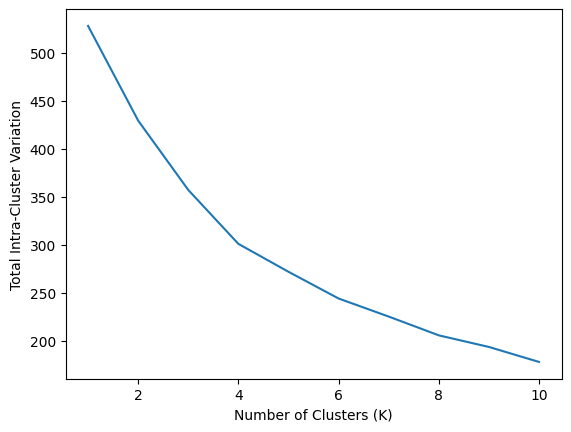

alt.Chart(...)

In [20]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import altair as alt
from sklearn.neighbors import NearestNeighbors


ou_df = pd.read_csv('gen9ou-1500.csv', encoding='utf-8', engine='python')
dex_df = pd.read_json('pokedex.json', encoding='utf-8')

threshold = 1.0
clean_ou = ou_df[ou_df['USG%'] > threshold]

#Get the set of OU mons
ou_names = set(clean_ou['Pokemon'])

# Filter the dex to only mons in OU
ou_dex = dex_df[dex_df['name'].isin(ou_names)]
ou_dex = ou_dex.merge(clean_ou[['Pokemon', 'Rank']], left_on='name', right_on='Pokemon', how='inner')
ou_dex = ou_dex.sort_values('Rank')

#To normalize, first we must flatten the stats out to their own columns
stats_df = ou_dex['baseStats'].apply(pd.Series)
pokemon = pd.concat([ou_dex.drop(columns=['baseStats']), stats_df], axis=1)

#Now we scale
scaler = StandardScaler()
pokemon[['hp', 'atk', 'def', 'spa', 'spd', 'spe']] = scaler.fit_transform(pokemon[['hp', 'atk', 'def', 'spa', 'spd', 'spe']])
clean_pokemon = pokemon.drop(columns=['num', 'Pokemon', 'genderRatio', 'abilities', 'heightm', 'weightkg', 'color', 'evos', 'eggGroups', 'cannotDynamax', 'requiredTeraType', 'prevo', 'evoLevel', 'otherFormes', 'formeOrder', 'canGigantamax', 'baseSpecies', 'forme', 'requiredItem', 'changesFrom', 'isCosmeticForme', 'requiredItems', 'evoCondition', 'evoType', 'gender', 'gen', 'evoItem', 'evoRegion', 'mother', 'canHatch', 'requiredAbility', 'battleOnly', 'requiredMove', 'evoMove', 'tags', 'baseForme', 'cosmeticFormes', 'maxHP'])

#Record the Total Intra-Cluster Variation
ticv = [] 

for k in range(1,11): 
    kmeans = KMeans(n_clusters=k, n_init=20)

    #Fit kmeans algorithm to the dataset
    kmeans.fit(clean_pokemon[['hp', 'atk', 'def', 'spa', 'spd', 'spe']])

    #Record the Total Intra-Cluster Variation for K=k
    ticv.append(kmeans.inertia_)

#Plot the elbow graph
plt.plot(range(1,11),ticv)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Total Intra-Cluster Variation')
plt.show()

#Based on the graph, the best k was 4, but that's a bit boring
kmeans = KMeans(n_clusters=7, n_init=20, random_state=42)

kmeans.fit(clean_pokemon[['hp', 'atk', 'def', 'spa', 'spd', 'spe']])

clean_pokemon['kmeans_role'] = kmeans.labels_

#We have the clusters, but what do they mean? Let's get the centroids and classify
centroids = kmeans.cluster_centers_
centroids_real = scaler.inverse_transform(centroids)
centroids_df = pd.DataFrame(centroids_real, columns = ['hp', 'atk', 'def', 'spa', 'spd', 'spe'])
centroids_df.index.name = 'cluster'

#Let's manually classify them based on the centroids dataframe
roles = {
    0: "Special Tank",
    1: "Physical Wallbreaker",
    2: "Special Sweeper",
    3: "Physical Wall",
    4: "Physical Sweeper",
    5: "Special Wall/Sponge/Util",
    6: "Physical Tank"
}

clean_pokemon['role'] = clean_pokemon['kmeans_role'].map(roles)

#Add in some sample teams from the Smogon forums
teams = {
    'team1': ['Torkoal', 'Hatterene', 'Raging Bolt', 'Slither Wing', 'Venusaur', 'Walking Wake'],
    'team2': ['Zamazenta', 'Ninetales-Alola', 'Darkrai', 'Ceruledge', 'Gliscor', 'Hatterene'],
    'team3': ['Kingambit', 'Deoxys-Speed', 'Great Tusk', 'Dragonite', 'Iron Moth', 'Primarina'],
    'team4': ['Ogerpon-Wellspring', 'Kingambit', 'Landorus-Therian', 'Glimmora', 'Dragapult', 'Iron Valiant'],
    'team5': ['Great Tusk', 'Kingambit', 'Raging Bolt', 'Walking Wake', 'Ninetales', 'Ceruledge'],
    'team6': ['Raging Bolt', 'Iron Treads', 'Ting-Lu', 'Gholdengo', 'Zamazenta', 'Tornadus-Therian'],
    'team7': ['Dragonite', 'Zamazenta', 'Landorus-Therian', 'Gholdengo', 'Darkrai', 'Hatterene'],
    'team8': ['Landorus-Therian', 'Samurott-Hisui', 'Pecharunt', 'Scizor', 'Latios', 'Zamazenta'],
    'team9': ['Great Tusk', 'Heatran', 'Weavile', 'Primarina', 'Ogerpon', 'Pecharunt'],
    'team10': ['Lokix', 'Cinderace', 'Great Tusk', 'Alomomola', 'Enamorus', 'Slowking-Galar'],
    'team11': ['Dragapult', 'Dragonite', 'Ting-Lu', 'Weezing-Galar', 'Iron Crown', 'Zapdos'],
    'team12': ['Garganacl', 'Dragapult', 'Ogerpon-Wellspring', 'Moltres', 'Zamazenta', 'Iron Treads'],
    'team13': ['Moltres', 'Zamazenta', 'Darkrai', 'Hydrapple', 'Ting-Lu', 'Tinkaton'],
    'team14': ['Samurott-Hisui', 'Tornadus-Therian', 'Pecharunt', 'Great Tusk', 'Clefable', 'Zamazenta'],
    'team15': ['Gliscor', 'Walking Wake', 'Slowking-Galar', 'Zamazenta', 'Ting-Lu', 'Kingambit'],
    'team16': ['Tyranitar', 'Gholdengo', 'Zamazenta', 'Rillaboom', 'Garchomp', 'Zapdos'],
    'team17': ['Gholdengo', 'Zamazenta', 'Ting-Lu', 'Clefable', 'Dragonite', 'Deoxys-Speed'],
    'team18': ['Kyurem', 'Corviknight', 'Ting-Lu', 'Dondozo', 'Slowking-Galar', 'Cinderace'],
    'team19': ['Dondozo', 'Blissey', 'Corviknight', 'Weezing-Galar', 'Gliscor', 'Toxapex'],
}

#Represent the Pokémon as roles for KNN. Must loop through each team and each Pokémon in the team
teams_with_roles = {
    team_name: [clean_pokemon.loc[clean_pokemon['name'] == pokemon, 'role'].values[0] 
                for pokemon in team_list]
    for team_name, team_list in teams.items()
}

#Lets just get all the roles in all the teams for visualization
all_roles = []
for team_roles in teams_with_roles.values():
    all_roles.extend(team_roles)

#Count frequency
role_counts = pd.Series(all_roles).value_counts().reset_index()
role_counts.columns = ['role', 'count']

#Altair bar chart
chart = alt.Chart(role_counts).mark_bar(color='red').encode(
    x='role',
    y='count'
).properties(
    title='Roles of Most Recommended Pokémon',
    width = 535,
    height = 350
)

def team_to_role_vector(team):
    classifications = [0]*7
    for mon in team:
        role = clean_pokemon.loc[clean_pokemon['name'] == mon, 'role'].values[0]
        role_idx = list(roles.values()).index(role)
        classifications[role_idx] += 1
    return classifications

#Convert sample teams into role classifications.
X = np.array([team_to_role_vector(team) for team in teams.values()])
team_names = list(teams.keys())

#Use Euclidean distance on role counts.
nn = NearestNeighbors(n_neighbors=3, metric='euclidean')
nn.fit(X)

def complete_team_knn(partial_team, team_size=6, top_k=3):
    #Convert partial team to role vector
    partial_classifications = np.array(team_to_role_vector(partial_team)).reshape(1, -1)
    
    #Find closest sample teams
    distances, indices = nn.kneighbors(partial_classifications)
    closest_teams = [team_names[i] for i in indices[0]]
    
    #Collect Pokémon from nearest teams
    recommended = []
    for team in closest_teams:
        for mon in teams[team]:
            if mon not in partial_team and mon not in recommended:
                recommended.append(mon)
    
    #Trim to fit team size
    return partial_team + recommended[:team_size - len(partial_team)]

clean_pokemon.to_json('clean_pokemon.json', orient='records', lines=False)  
centroids_df.to_json('centroids_df.json', orient='records', lines=False)   

chart 

# Example

In [19]:
partial_team = ["Blaziken", "Dragonite", "Gliscor", "Samurott-Hisui"]
completed_team = complete_team_knn(partial_team)
print(completed_team)

['Blaziken', 'Dragonite', 'Gliscor', 'Samurott-Hisui', 'Landorus-Therian', 'Pecharunt']


# Don't like the result? Pick your own Pokémon instead!

In [8]:
#Selection: pick a role

dropdown = alt.binding_select(
    options=[None] + list(clean_pokemon['role'].unique()), 
    name='Select role: '
)
role_select = alt.selection_point(fields=['role'], bind=dropdown, empty='all')

chart = alt.Chart(clean_pokemon).mark_point(filled=True, size=200).encode(
    x=alt.X('role:N', title='Role'),
    y=alt.Y('name:N', title='Pokémon'),
    color='role:N',
    tooltip=['name', 'role']
).add_params(
    role_select
).transform_filter(
    role_select
).properties(
    width=500,
    height=700,
    title='Select Roles to See Pokémon'
)

chart

alt.Chart(...)